In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset") #dataset path
path+="/healthcare-dataset-stroke-data.csv"

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

kaggle 에서 stroke prediction dataset을 가져왔음

pandas와 sklearn 라이브러리를 사용해서 데이터를 수집, 가공 후

pytorch와 친해지기 위해서 모델은 pytorch에서 가져옴

sklearn은 내부적으로 tree구조를 사용해 모든 점 사이의 거리를 계산하지 않고 가능성이 있는 점들만 계산한다는 장점

pytorch는 gpu를 사용해 모든 점 사이의 거리를 계산하지만 데이터가 매우 클때는 압도적으로 sklearn보다 빠르게 처리가능 / 직접구현이 번거롭다

In [ ]:
def load_data(csv_path):
  data = pd.read_csv(csv_path)
  print(data.head())
  print()
  print(data.info())
  print()
  print(data.isna().sum())
  print()
  print(data.describe())
  print()
  print(data.nunique())
  return data

In [ ]:
data = load_data(path)
'''
5110명 중 201명이 na포함 -> 모두 bmi지수에 대해서 na
5개의 categorical
7개가 numerical

id, stroke은 학습시 빼면되고
hypertension, heart_disease는 encoding된 categorical
5개 categorical encoding 하면됨
이때 각각 cardinality가 작음.. -> one-hot encoding쓰면됨
'''

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 

'\n5110명 중 201명이 na포함 -> 모두 bmi지수에 대해서 na\n5개의 categorical\n7개가 numerical\n\nid, stroke은 학습시 빼면되고\nhypertension, heart_disease는 encoding된 categorical\n5개 categorical encoding 하면됨\n이때 각각 cardinality가 작음.. -> one-hot encoding쓰면됨\n'

In [ ]:
def analyze_missing_pattern(data, na_feature, analysis_feature):
  data['is_missing'] = data[na_feature].isna()

  plt.figure(figsize = (12, 7))
  sns.set_style('whitegrid')

  if pd.api.types.is_numeric_dtype(data[analysis_feature]):
    plt.subplot(1,2,1)
    sns.kdeplot(data = data, x = analysis_feature, hue = 'is_missing', fill = True, common_norm = False) #common_norm -> 각 그룹 PDF를 독립적으로 normalizing
    plt.title(f'Density of "{analysis_feature}"\nby missingness of "{na_feature}"', fontsize = 14)

    plt.subplot(1,2,2)
    sns.boxplot(data = data, x = 'is_missing', y = analysis_feature)
    plt.title(f'Boxplot of "{analysis_feature}"\nby missingness of "{na_feature}"', fontsize = 14)
    plt.xlabel(f'Is "{na_feature}" Missing?')
  else:
    sns.histplot(data = data, x = analysis_feature, hue = 'is_missing', multiple = 'fill', shrink = 0.8)
    plt.title(f"Proportion of '{analysis_feature}' Categories\nby missingness of'{na_feature}'", fontsize = 14)
    plt.ylabel("Proportion")

  plt.tight_layout()
  plt.show()


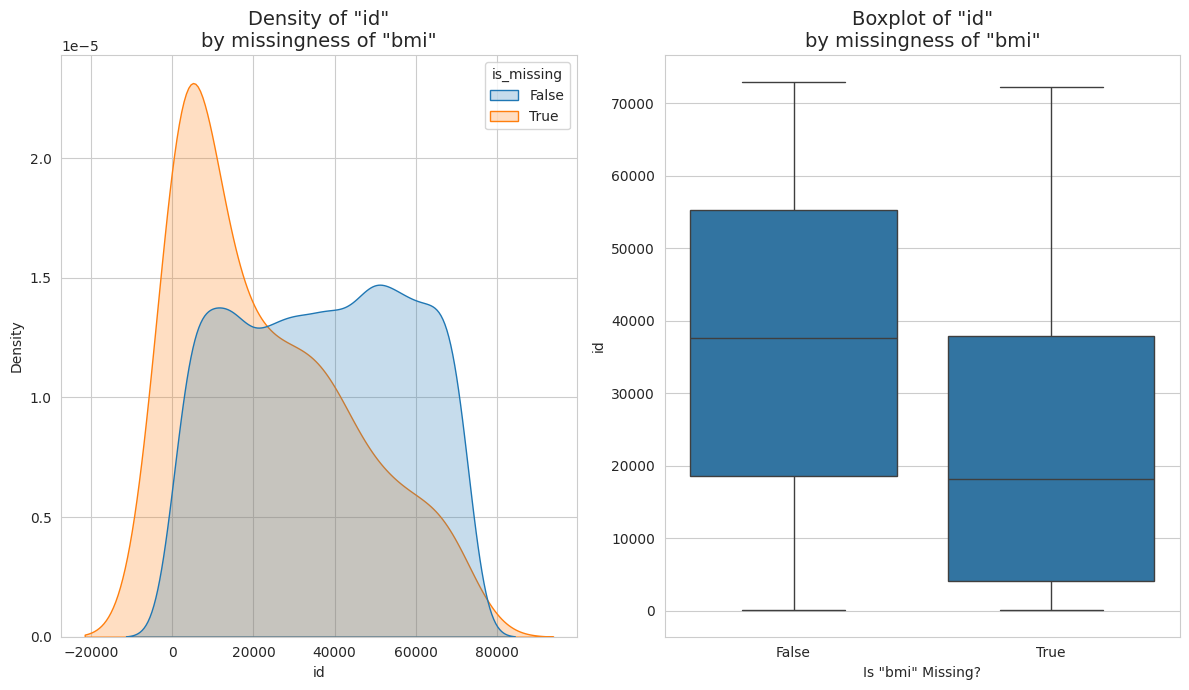

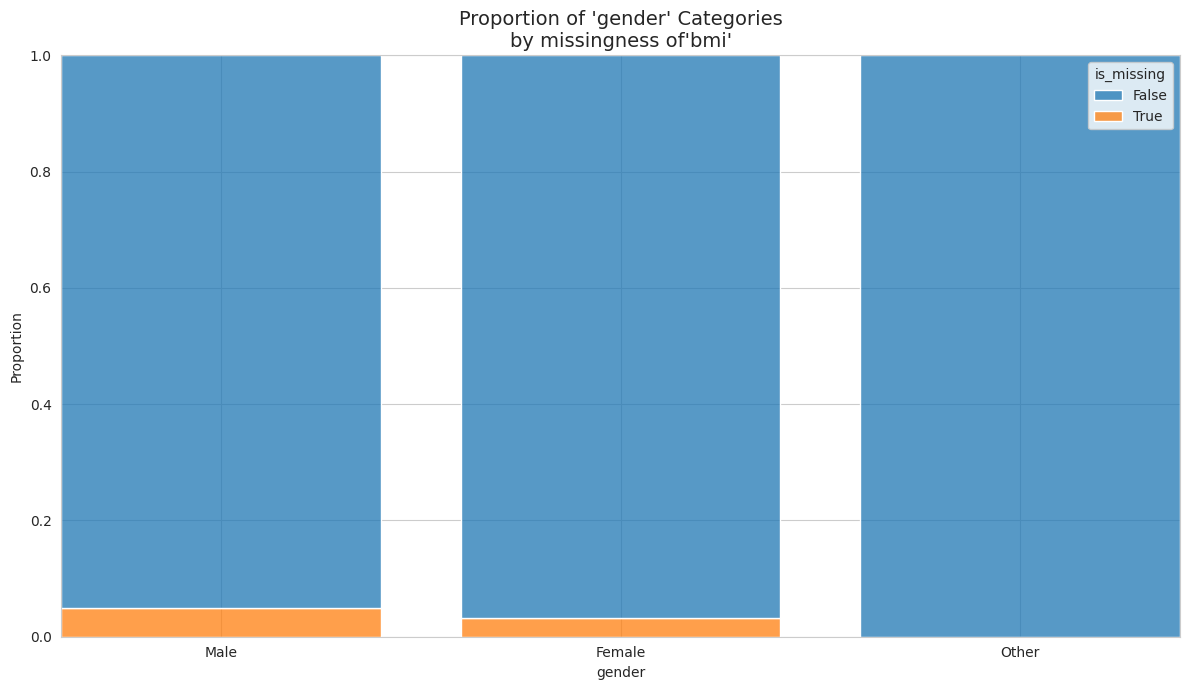

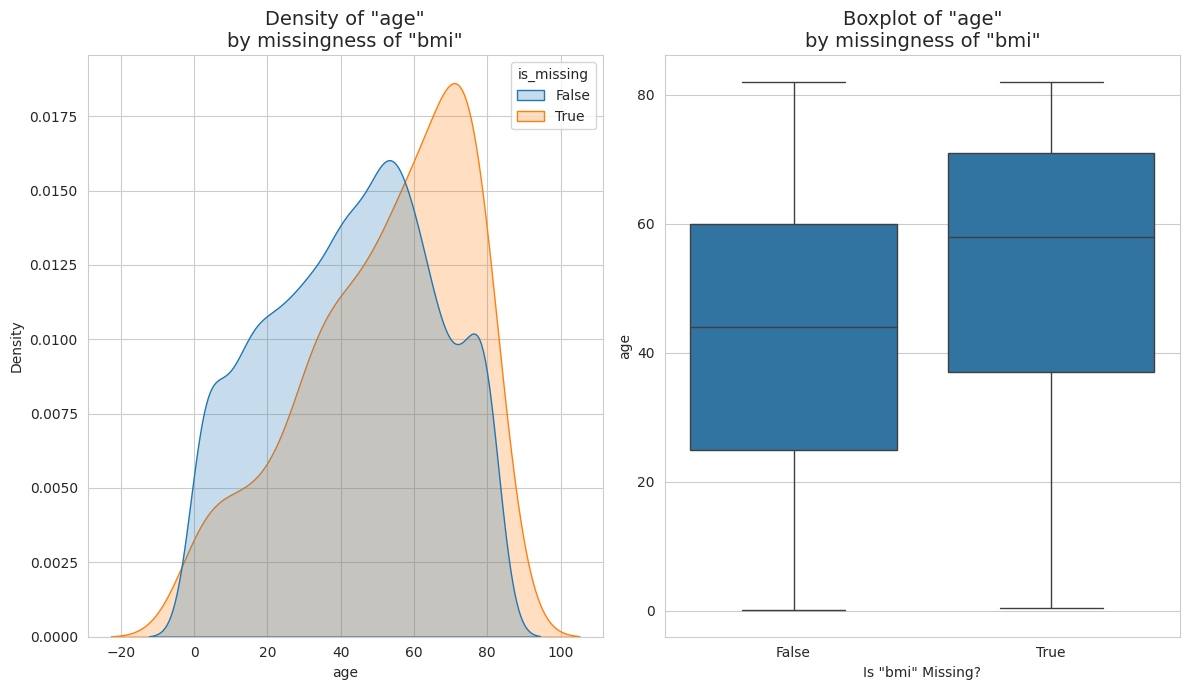

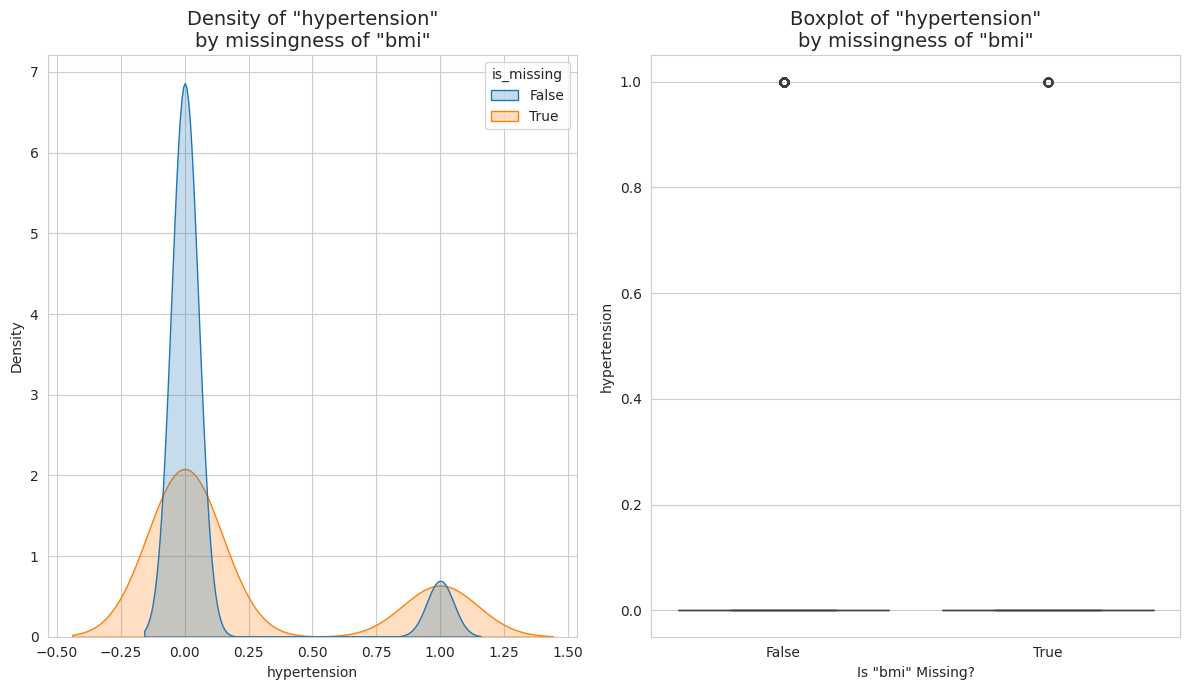

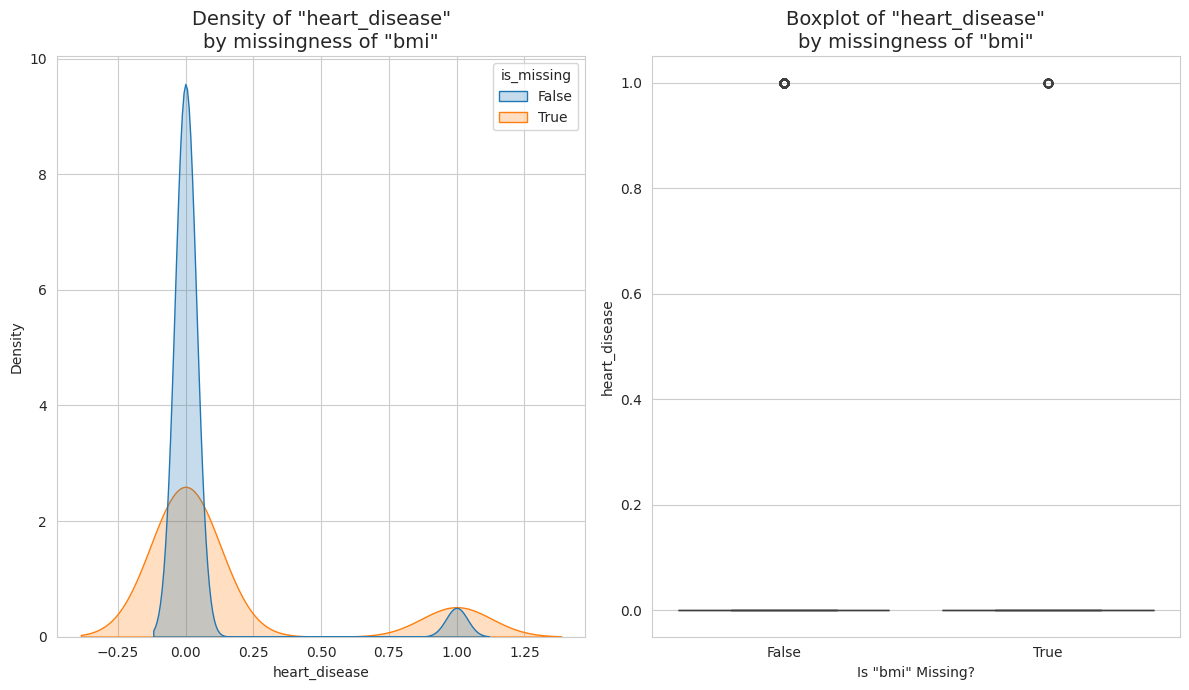

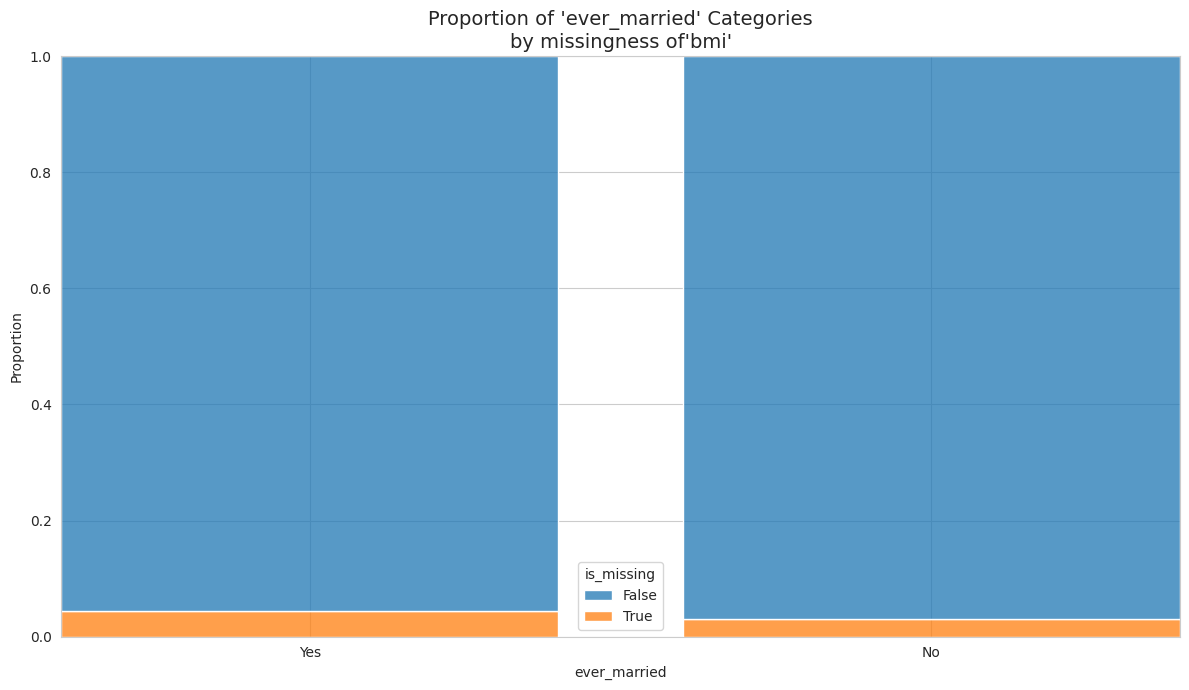

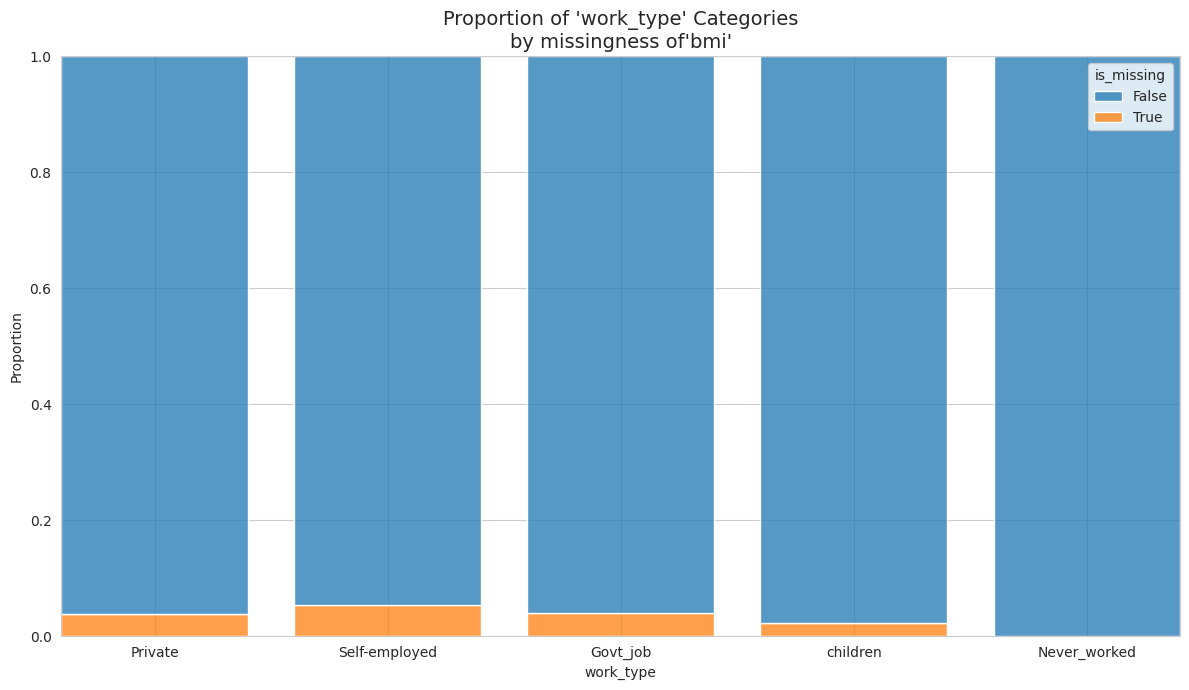

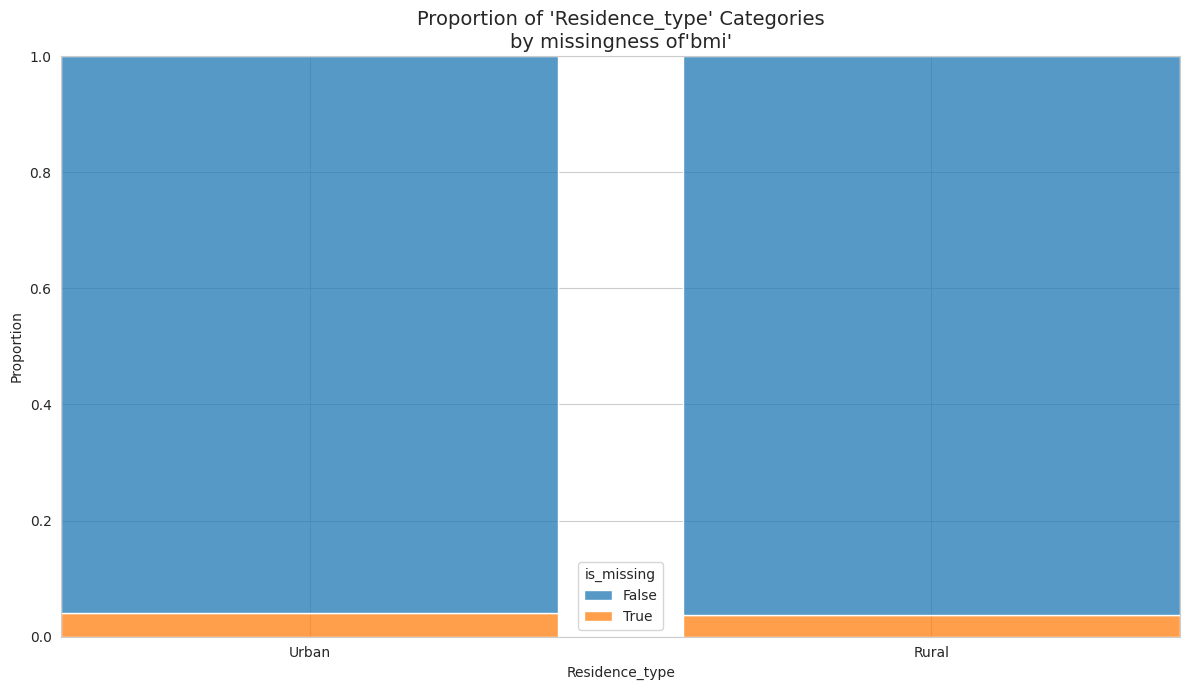

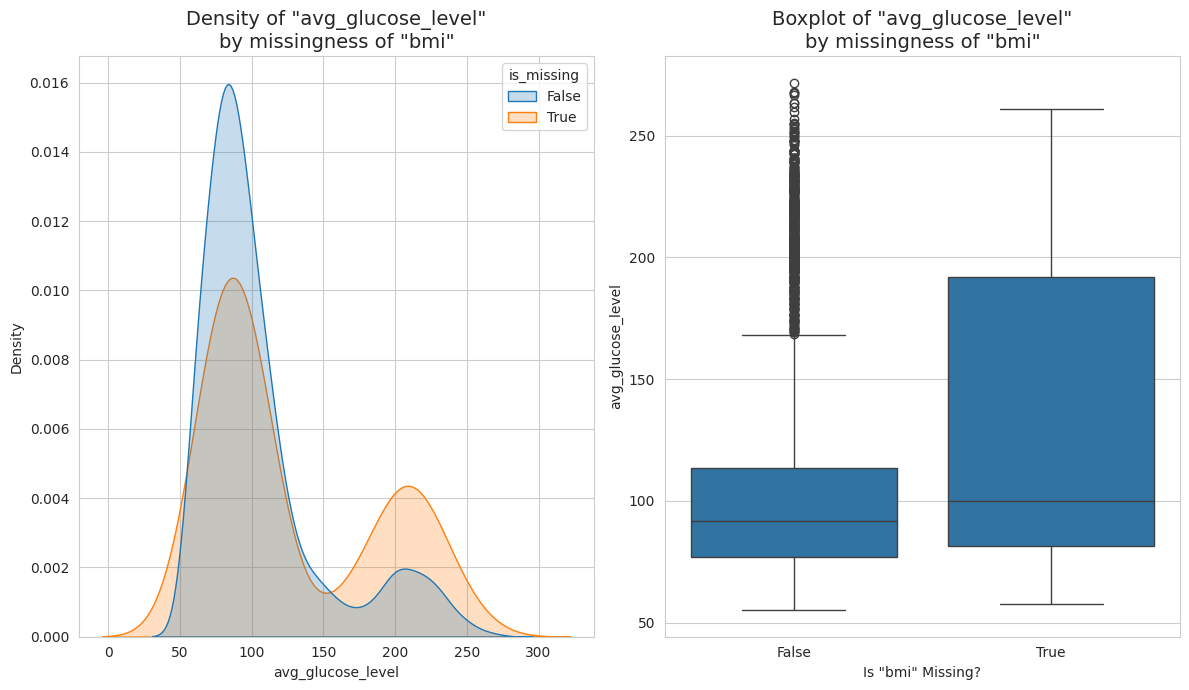

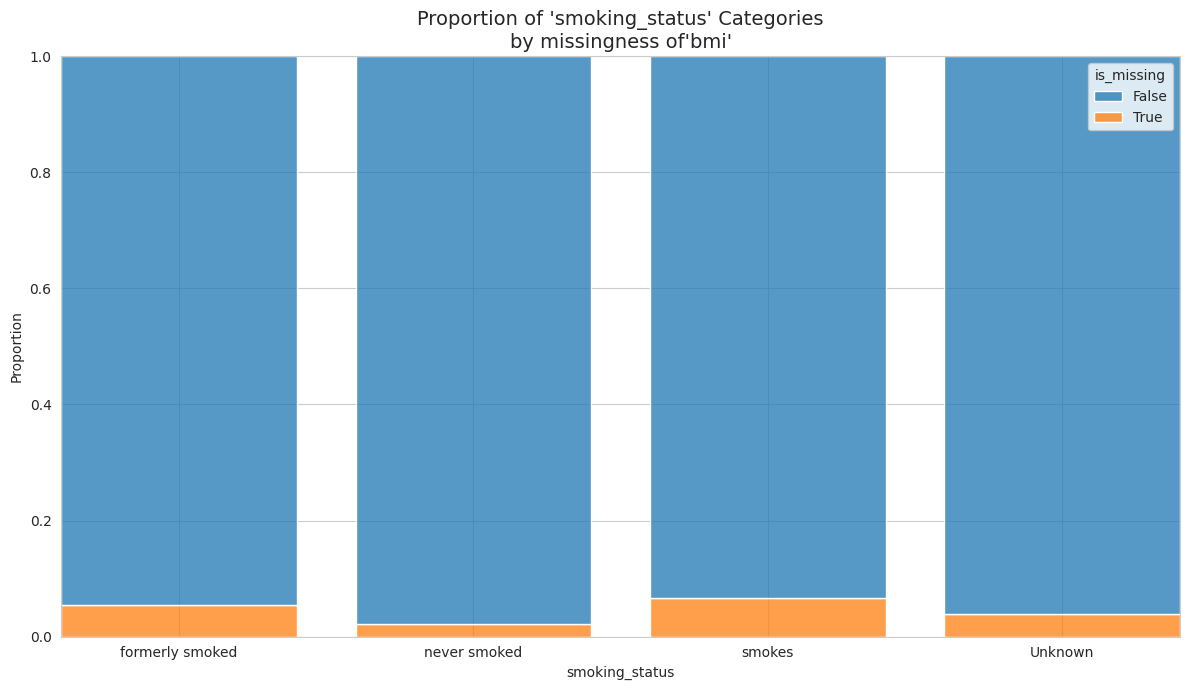

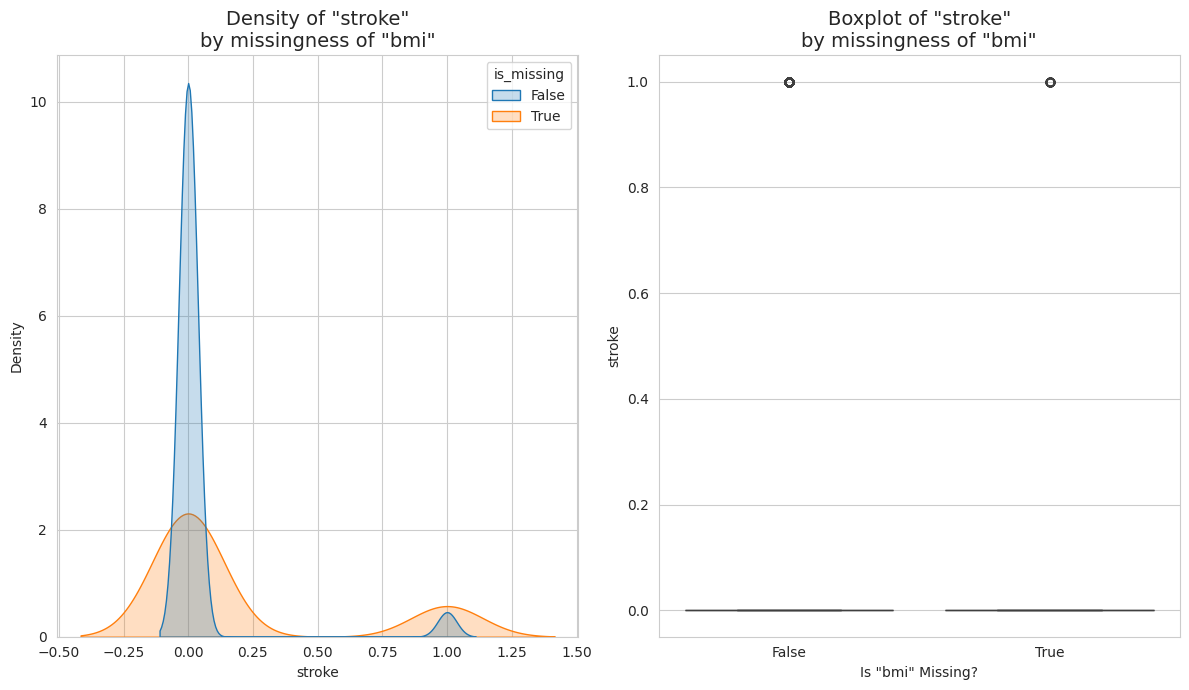

In [ ]:
for i in data.columns:
  if i != 'bmi' and i != 'is_missing':
    analyze_missing_pattern(data, 'bmi', i)

random하게 bmi가 na로 분포되어있음.. 딱히 패턴으로 보이는게 없음

5110중에 201개니깐 무시할 수 없는 개수..

knn을 이용해 비슷한 사람들의 값으로 대체할 예정

In [ ]:
# 데이터셋 split
x = data.drop(columns = ['id', 'stroke', 'is_missing'])
y = data['stroke']
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y,
    test_size = 0.3,
    random_state = 42,
    stratify=y
    )
y_test

,stroke
4223,0
2230,0
4612,0
4100,0
2983,0
...,...
1765,0
3103,0
4522,0
624,0


In [ ]:
# categorical -> encoding
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

numeric_features = x_train_val.select_dtypes(include = np.number).columns.tolist()
categorical_features = x_train_val.select_dtypes(exclude = np.number).columns.tolist()


#보통 scaling을 하기전에 imputation을함
#knn-imputer를 쓸거면 scaling을 통해서 imputation에 영향이 없게 scaling먼저 진행
#knn-imputer + standardization를 쓴거 보다는 Simple Imputer+minmax가 좀 더 나은 결과를 보였음
numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
])
categorical_transformer = OneHotEncoder(handle_unknown = 'ignore')

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder = 'passthrough' #명시되지 않았으면 그냥 통과
)

x_train_p = preprocessor.fit_transform(x_train_val)
x_test_p = preprocessor.transform(x_test)


print(x_train_p)

[[0.63378906 0.         0.         ... 1.         0.         0.        ]
 [0.75585938 0.         0.         ... 0.         0.         0.        ]
 [0.98779297 0.         1.         ... 0.         0.         0.        ]
 ...
 [0.74365234 0.         0.         ... 1.         0.         0.        ]
 [0.97558594 0.         0.         ... 0.         1.         0.        ]
 [0.07226562 0.         0.         ... 0.         0.         0.        ]]


#KNN

In [ ]:
import torch

def knn(x_train, y_train, x_test, k):
  '''
  train data와 test data 각각 모든 거리를 구한 후 행렬에 저장
  각 test data에 가까운 k개의 점의 index 저장
  index기반으로 해당 train data의 label값 가져와
  그 중 가장 빈번한 label 찾고 prediction을 확정함
  '''
  distances = torch.cdist(x_test, x_train) # 각 test와 train 점사이 euclidean dist -> matrix로

  top_k_indices = torch.topk(distances, k, dim=1, largest = False).indices #위에서 계산한 matrix를 바탕으로 test와 가까운 k개의 점을 가져옴

  neighbor_labels = y_train[top_k_indices] #해당되는 점들의 label가져옴

  predictions = torch.mode(neighbor_labels, dim = 1).values #dim=1 -> 행별로 가장 빈번하게 나타나는 라벨을 찾고 / values -> 실제 라벨 값을 가져옴

  return predictions

In [ ]:
x_train_t = torch.tensor(x_train_p, dtype = torch.float32)
x_test_t = torch.tensor(x_test_p, dtype = torch.float32)
y_train_t = torch.tensor(y_train_val, dtype = torch.float32)


In [ ]:
y_test.value_counts()

,count
stroke,
0,1458
1,75


In [ ]:
y_test_pred = knn(x_train_t, y_train_t, x_test_t, 5)
y_test_pred = y_test_pred.numpy()
y_test_pred

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

0.949119373776908


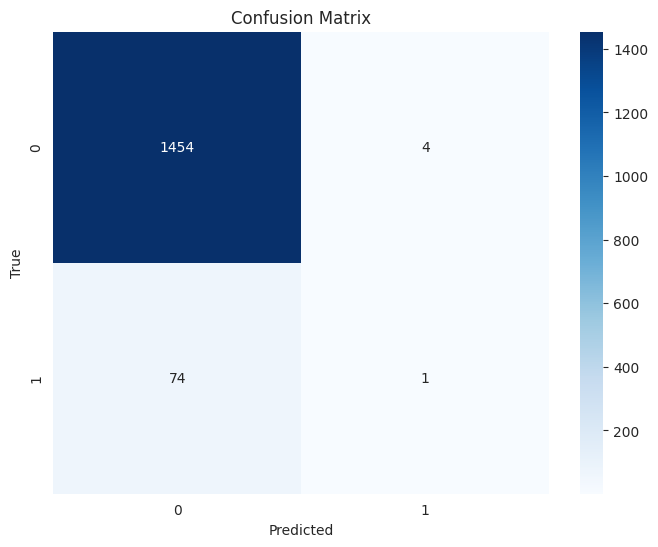

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.20      0.01      0.03        75

    accuracy                           0.95      1533
   macro avg       0.58      0.51      0.50      1533
weighted avg       0.91      0.95      0.93      1533



'\nk=1 그나마 예측..? stroke에 대해 예측을 못함.. 아닌 사람은 괜찮은데 / k>1이면 0만.. overfitting\n'

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test, y_test_pred))
conf = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize =(8,6))
sns.heatmap(conf, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_test_pred)) #정밀도, 재현율, f1-score, (support)해당 클래스에 속하는 실제 데이터 수

'''
k=1 그나마 예측..? stroke에 대해 예측을 못함.. 아닌 사람은 괜찮은데 / k>1이면 0만.. overfitting
'''

0.9406392694063926


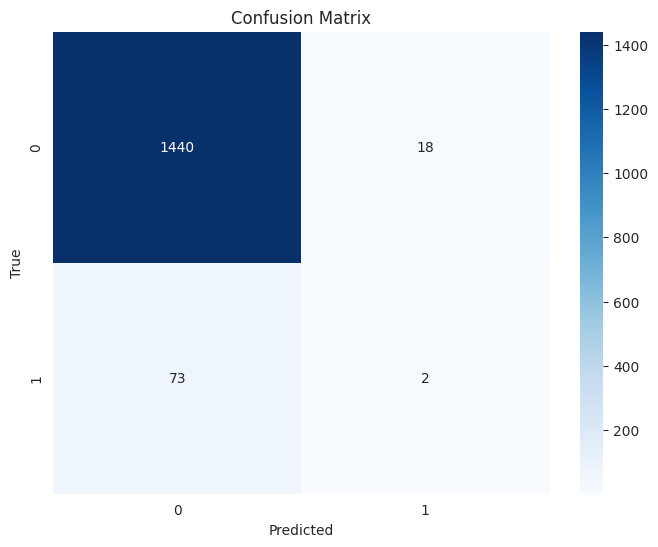

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1458
           1       0.10      0.03      0.04        75

    accuracy                           0.94      1533
   macro avg       0.53      0.51      0.51      1533
weighted avg       0.91      0.94      0.92      1533



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

m_test = KNeighborsClassifier(n_neighbors = 3)
m_test.fit(x_train_t, y_train_t)
y_test_pred = m_test.predict(x_test_t)
print(accuracy_score(y_test, y_test_pred))
conf = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize =(8,6))
sns.heatmap(conf, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_test_pred))

모델 잘못 짠거아니고 데이터 크기 문제인듯...

test의 크기를 10프로로 하니깐 neighbors가 2이상이면 무조건 0을 뱉는 의미없는 모델이 됨

20, 30프로일 때는 조금 나아지고 그래도 아직 예측에 사용할 수 있는 모델은 아님...


1. 일단 stroke 환자에 대한 정보가 너무 적음

    그래서 neighbors가 2이상이면 0만 나오게 됨..
2. train의 데이터 크기도 중요하지만 validation 데이터의 크기도 중요하다는 걸 알게 되었군(여기서는 test지만)


# perceptron

In [ ]:
# import numpy as np

# weights = np.random.rand(x_train_p.shape[1])
# bias = np.random.rand(1) #perceptron으로 예측하는 거니깐

# learning_rate = 0.05
# epochs = 50
# acc_history = list()

# def step_function(x):
#   return (x>=0).astype(int)

# for epoch in range(epochs):
#   total_input = x_train_p@weights + bias
#   prediction = step_function(total_input)
#   err = y_train_val - prediction
#   weights += learning_rate * (x_train_p.T @ err)
#   bias += learning_rate * np.sum(err)
#   acc_history.append(np.mean(prediction == y_train_val)) #prediction과 y_train_val을 비교해서 0 혹은 1 / 평균 => acc

In [ ]:
import numpy as np

class Perceptron:
  def __init__(self, learning_rate, epochs):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.weights = None
    self.bias = None

  def step_function(self, z):
    return np.where(z>=0, 1, 0) #z>=0 이면 1

  def fit(self, x, y):
    self.weights = np.random.rand(x.shape[1]) #feature의 수만큼 weight값 필요
    self.bias = np.random.rand(1) #perceptron이기 때문에 1개의 bias만 있으면 됨
    for epoch in range(self.epochs):
      total_input = x@self.weights + self.bias #선형 변환
      prediction = self.step_function(total_input) #활성화 함수
      err = y - prediction #손실 계산
      self.weights += self.learning_rate * (x.T @ err) #손실 값, 학습률 기반으로 가중치 업데이트
      self.bias += self.learning_rate * np.sum(err) # 손실 값, 학습률 기반으로 편향 업데이트

  def predict(self, x):
    z = x @ self.weights + self.bias
    predict = self.step_function(z)
    return predict


In [ ]:
p = Perceptron(0.05, 50)
p.fit(x_train_p, y_train_val)
y_test_pred = p.predict(x_test_p)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.00      0.00      0.00        75

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.90      0.95      0.93      1533



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# SVM

In [ ]:
'''
간단하게 n dimension에서 hyperplane을 통한 데이터의 분류임
그럼 이걸 어떻게 표현하게 되고 어떻게 구현해야되냐...? -> 이거에 대해서는 생각해본적이없음
근데 간단함.. ax+by+cz+..... + 상수 = 0으로 hyperplane이 표현가능할테니
우리가 항상 봐왔던 wx+b = 0 즉 선형 결합의 형태로 표현이 된다

좀 더 자세하게 들어가보자
wx+b = 0이 decision boundary가 된다면
양옆으로 wx+b = c / wx+b = -c 라는 support vector를 품고있는 평면이 있음
w,b는 미지수이고 c는 상수니깐 계산의 편의를 위해서 c에 대해서 그냥 나눠버리면 식은 간단해지고 우리가 구해야하는 w,b에 대한 표현도 해치지 않게됨
wx+b = 1 / wx+b = -1이 positive, negative 마진의 경계가 됨

  1. hinge loss : max(0,1-y*y^hat)
  여기서는 마진의 안쪽에 분포할 수 없게 만들어 주는 역할
  어떤 x를 넣었을 때 wx+b 즉 y^hat의 값이 1과 같거나 커야하고 혹은 -1과 같거나 작아야함
  이걸 수식으로 어떻게 제한할까
  정답인 y가 1혹은 -1의 값을 갖는 것을 통해
  y*y^hat>=1으로 표현할 수 있음
  1보다 작게되면 우리는 패널티를 줘야함(크거나 같을 때는 패널티를 줄 필요없지요)
  그래서 max(0, 1-y*y^hat으로 표현하게 됨)

  2. L2 Regularization : lambda*(w의 L2 norm)^2
  margin의 폭을 최대화 해주는 역할
  wx+b = 1
  wx+b = -1
  이 두개가 마진의 경계이니 마진의 폭은 이 둘의 최단 거리임
  정사영을 이용해서 마진의 폭 = (2)/(w의 L2 norm)
  이를 최대화 하는 것이기 때문에 w의 l2 norm을 최소화하는 것임
  l2 norm자체를 최소화하려면 루트가 씌여있어서 미분하기 까다롭기 때문에 제곱을해서 풀어줌
  그러면 min(||w||^2)이 최종 목표가 되고

    ???근데 왜 여기서 l2 regularization을 쓸까..? l1도 있잖아
    우선 margin의 폭에서 l2 norm을 써서 나타내기 때문에 l2 regularization을 사용
    그리고 미분해야하는데 l1은 절대값이라 미분하기 불편 그에 반해 l2는 미분하기 편함
    l1즉 lasso는 덜중요한 가중치를 정확히 0으로 만들어버림 / 중요한 특성만 선택
    ridge는 모든 가중치가 전반적으로 작아지도록(분산되도록) 만듬


1, 2를 최소화해야 하고 수식화해서 나타내면
Total Loss = sigma max(0, 1-y*y^hat) + lambda*||w||^2
로 표현할 수 있음

'''
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class LinearSVM(nn.Module): #nn.module 상속받음
  def __init__(self, n_features):
    super(LinearSVM, self).__init__()
    self.linear = nn.Linear(n_features , 1)


  def forward(self, x): #nn.module의 __call__()에 의해 자동으로 객체 호출시 같이 실행됨
    '''
    wx+b의 raw score를 그대로 반환
      activation없이 뱉는다는 말
    '''
    return self.linear(x)

  def fit(self, x_train, y_train, learning_rate = 0.05, epochs = 200, lambda_param = 0.01):
    #parameters()는 self.linear.weight와 self.linear.bias를 포함
    optimizer = optim.SGD(self.parameters(), lr = learning_rate)

    for epoch in range(epochs):
      #forward pass
      y_pred = self(x_train)

      #hinge loss계산 max(0, 1-y*y^hat)
      margin = y_train * y_pred
      hinge_loss = 1 - margin
      hinge_loss[hinge_loss < 0] = 0 #max()의 연산을 해줌
      hinge_loss_mean = torch.mean(hinge_loss)

      #L2 Regularization
      reg_loss = lambda_param * torch.sum(self.linear.weight ** 2)

      #Total Loss
      total_loss = hinge_loss_mean + reg_loss

      #Backward Pass, Optimization
      optimizer.zero_grad() #이전 grad 초기화
      total_loss.backward() #grad 계산
      optimizer.step() #가중치 업데이트

    return self

  def predict(self, x_test):
    self.eval() #모델을 eval mode로 / 반대로는 train mode
    #사용이유는 train시 batch normalization, drop out, ...을 사용할텐데
    #이들은 evaluation 또는 inference시에는 동작하면 안되기 때문에 eval()을 통해서 꺼주는 거임

    #grad 계산 비활성화 (메모리 절약)
    with torch.no_grad(): #우리는 기울기를 inference단계에서 계산할 필요가 없으므로 계산과정을 tracking할 이유가 없다
      raw_scores = self(x_test) #forward() 호출

      #wx+b가 0이하면 -1 초과면 1
      predictions = torch.where(raw_scores<=0, -1, 1)

    return predictions.numpy() #numpy로 return

In [ ]:
#y의 0값을 -1로 변환이 필요함
#우리는 -1과 1로 예측하기 때문
y_test[y_test==0] = -1
y_train_t[y_train_t==0] = -1

model = LinearSVM(x_train_t.shape[1])
model.fit(x_train_t, y_train_t,)
y_test_pred = model.predict(x_test_t)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

          -1       0.95      1.00      0.97      1458
           1       0.00      0.00      0.00        75

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.90      0.95      0.93      1533



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_test[y_test==-1] = 0
#다시 변환

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train_p, y_train_val)
y_test_pred = model.predict(x_test_p)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.33      0.01      0.03        75

    accuracy                           0.95      1533
   macro avg       0.64      0.51      0.50      1533
weighted avg       0.92      0.95      0.93      1533



In [ ]:
y_test

,stroke
4223,0
2230,0
4612,0
4100,0
2983,0
...,...
1765,0
3103,0
4522,0
624,0


# naive bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train_p, y_train_val)
y_test_pred = model.predict(x_test_p)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40      1458
           1       0.06      0.99      0.12        75

    accuracy                           0.29      1533
   macro avg       0.53      0.62      0.26      1533
weighted avg       0.95      0.29      0.39      1533



# Data Augmentation

100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s]


실험시작 : Augmentation X
Epoch [1/20], Loss: 3.0796, Train Acc: 10.26%
Epoch [2/20], Loss: 2.3075, Train Acc: 10.02%
Epoch [3/20], Loss: 2.3069, Train Acc: 10.19%
Epoch [4/20], Loss: 2.3070, Train Acc: 10.22%
Epoch [5/20], Loss: 2.3074, Train Acc: 9.96%
Epoch [6/20], Loss: 2.3073, Train Acc: 10.09%
Epoch [7/20], Loss: 2.3068, Train Acc: 10.19%
Epoch [8/20], Loss: 2.3065, Train Acc: 9.92%
Epoch [9/20], Loss: 2.3075, Train Acc: 10.00%
Epoch [10/20], Loss: 2.3070, Train Acc: 10.03%
Epoch [11/20], Loss: 2.3071, Train Acc: 9.91%
Epoch [12/20], Loss: 2.3075, Train Acc: 10.05%
Epoch [13/20], Loss: 2.3069, Train Acc: 10.10%
Epoch [14/20], Loss: 2.3073, Train Acc: 9.85%
Epoch [15/20], Loss: 2.3071, Train Acc: 9.87%
Epoch [16/20], Loss: 2.3071, Train Acc: 10.06%
Epoch [17/20], Loss: 2.3070, Train Acc: 9.98%
Epoch [18/20], Loss: 2.3074, Train Acc: 10.01%
Epoch [19/20], Loss: 2.3073, Train Acc: 9.91%
Epoch [20/20], Loss: 2.3076, Train Acc: 9.99%
훈련 종료
Test Accuracy: 10.00%
실험시작 : Augmentation O
Epoch

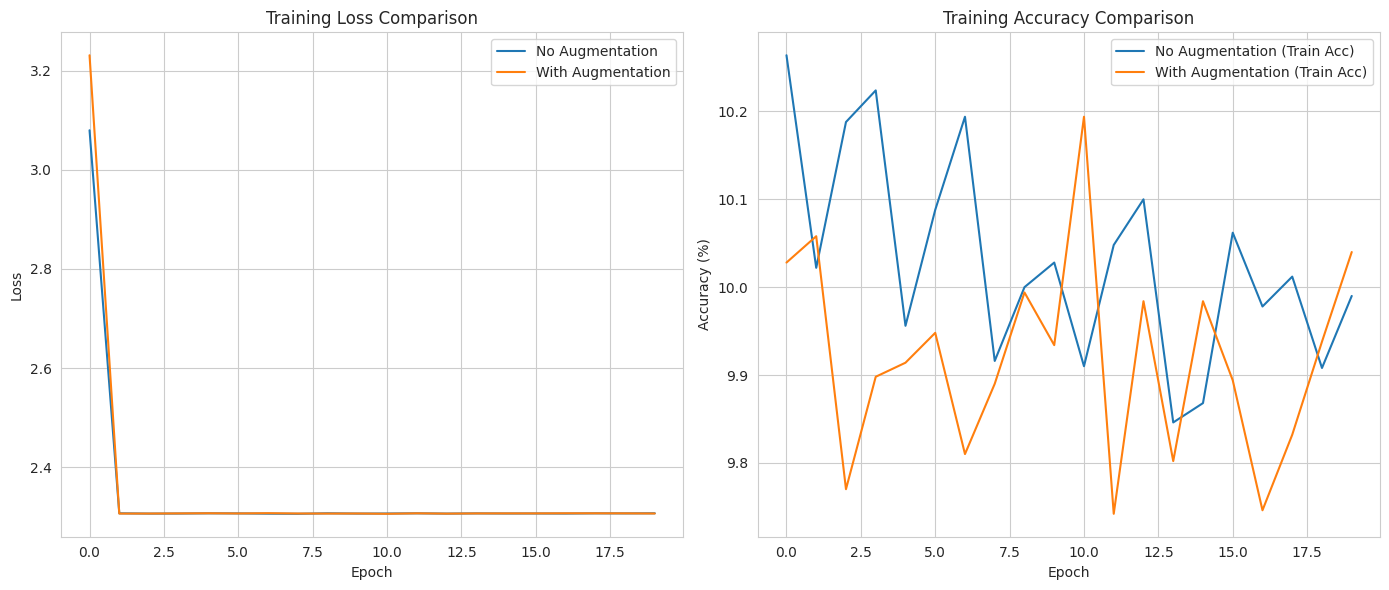

In [ ]:
import torchvision
import torchvision.transforms as transforms


epochs = 20
batch_size = 64
learning_rate = 0.05
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#ToTensor()를 통해 데이터를 0, 1 범위로 바꾼이후에
#평균 0.5, 0.5, 0.5로 std도 0.5, 0.5, 0.5로 normalize
#이것은 -1에서 1의 범위로 바꾸는 것 과 같음
#이것은 zero-centered output과 유사한 효과를 주고 weight가 한쪽으로 쏠리는 지그재그 현상을 줄여주고 경사하강법이 더 빠르고 안정적으로 수렴하게 도와줌
transform_normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transform_normalize
])

transform_with_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomVerticalFlip(p = 0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transform_normalize
])

#dataset은 원본데이터 / dataloader는 mini-batch단위로 꺼내 모델에 넘겨줌
#shuffle은 넘겨줄 때 데이터의 순서를 매 epoch마다 무작위로 섞음
#모델이 데이터의 순서까지 학습할 수도 있음
#이를 통해 overfitting 방지 가능
train_set_no_aug = torchvision.datasets.CIFAR10(root = './data', train = True,
                                                download = True, transform = transform_no_aug)
train_loader_no_aug = torch.utils.data.DataLoader(train_set_no_aug, batch_size = batch_size, shuffle = True)

train_set_with_aug = torchvision.datasets.CIFAR10(root = './data', train = True,
                                                  download = True, transform = transform_with_aug)
train_loader_with_aug = torch.utils.data.DataLoader(train_set_with_aug, batch_size = batch_size, shuffle = True)

test_set = torchvision.datasets.CIFAR10(root = './data', train = False,
                                        download = True, transform = transform_no_aug)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle = False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    #input = 32x32x3
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 5, padding = 2)
    #32x32x16
    self.pool1 = nn.MaxPool2d(kernel_size = 2, stride=2)
    #16x16x16
    self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 5, padding = 2)
    #16x16x32
    self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
    #8x8x32

    #Flatten = 8*8*32 = 2048
    self.fc1 = nn.Linear(32*8*8, 120)
    self.fc2 = nn.Linear(120, 10) #10개의 클래스로 나뉨
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.pool1(self.relu(self.conv1(x)))
    x = self.pool2(self.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = self.relu(self.fc1(x))
    x = self.fc2(x)

    return x

def train_one_epoch(model, train_loader, criterion, optimizer):
  model.train() #train mode

  running_loss = 0.0
  correct_train = 0
  total_train = 0

  for images, labels in train_loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    outputs = model(images) #forward
    loss = criterion(outputs, labels)

    optimizer.zero_grad() #초기화
    loss.backward() #grad계산
    optimizer.step() #update

    running_loss += loss.item() * images.size(0) #running_loss는 해당 epoch에서 처리한 모든 샘플의 손실 총합
    #따라서 미니 배치의 평균인 loss.item()에 샘플의 개수인 images.size(0)을 곱함

    _, predicted = torch.max(outputs.data, 1)
    total_train += labels.size(0)
    correct_train += (predicted == labels).sum().item()

  epoch_loss = running_loss / total_train
  epoch_acc = 100 * correct_train / total_train
  return epoch_loss, epoch_acc

def evaluate(model, test_loader):
  model.eval()

  correct_test = 0
  total_test = 0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(DEVICE), labels.to(DEVICE)

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)

      total_test += labels.size(0)
      correct_test += (predicted == labels).sum().item()

  test_acc = 100*correct_test / total_test
  return test_acc

def run_exp(name, train_loader):
  print(f"실험시작 : {name}")

  model = SimpleCNN().to(DEVICE)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = learning_rate)

  history_loss = []
  history_train_acc = []

  for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)

    history_loss.append(train_loss)
    history_train_acc.append(train_acc)

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')

  print('훈련 종료')

  test_accuracy = evaluate(model, test_loader)
  print(f'Test Accuracy: {test_accuracy:.2f}%')

  return history_loss, history_train_acc, test_accuracy


hist_no_aug = run_exp("Augmentation X", train_loader_no_aug)
hist_with_aug = run_exp("Augmentation O", train_loader_with_aug)

print("\n--- [실험 결과 요약] ---")
print(f"증강 (X) 테스트 정확도: {hist_no_aug[2]:.2f}%")
print(f"증강 (O) 테스트 정확도: {hist_with_aug[2]:.2f}%")

# --- 6. 훈련 과정 시각화 ---
plt.figure(figsize=(14, 6))

# 그래프 1: 훈련 손실(Loss) 비교
plt.subplot(1, 2, 1)
plt.plot(hist_no_aug[0], label='No Augmentation')
plt.plot(hist_with_aug[0], label='With Augmentation')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# 그래프 2: 훈련 정확도(Accuracy) 비교
plt.subplot(1, 2, 2)
plt.plot(hist_no_aug[1], label='No Augmentation (Train Acc)')
plt.plot(hist_with_aug[1], label='With Augmentation (Train Acc)')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


